In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from statsmodels.tsa.arima.model import ARIMA # 아리마 
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf # 우리 이거 볼거예요 예 
from statsmodels.tsa.seasonal import seasonal_decompose # 계절성 어쩌고 분석하는 그거 

In [2]:
work_df = pd.read_csv('data/walking_distance.csv', skiprows=1)

work_df['startDate'] = pd.to_datetime(work_df['startDate'])
work_df['endDate'] = pd.to_datetime(work_df['endDate'])

print(work_df.columns) # 컬럼명이 리스트로 잘 나오는지 확인
work_df.head()         # 상위 5개 데이터가 표 형태로 나오는지 확인

Index(['type', 'sourceName', 'sourceVersion', 'productType', 'device',
       'startDate', 'endDate', 'unit', 'value'],
      dtype='object')


,type,sourceName,sourceVersion,productType,device,startDate,endDate,unit,value
0,HKQuantityTypeIdentifierDistanceWalkingRunning,iPhone,18.1.1,"iPhone11,6","<<HKDevice: 0x1319f1e00>, name:iPhone, manufac...",2024-12-29 05:06:36+00:00,2024-12-29 05:16:37+00:00,km,0.567740
1,HKQuantityTypeIdentifierDistanceWalkingRunning,양탕국,18.2,"iPhone16,2","<<HKDevice: 0x1319f1c80>, name:iPhone, manufac...",2024-12-29 05:07:05+00:00,2024-12-29 05:09:18+00:00,km,0.093088
2,HKQuantityTypeIdentifierDistanceWalkingRunning,양탕국,18.2,"iPhone16,2","<<HKDevice: 0x1319f1c80>, name:iPhone, manufac...",2024-12-29 05:09:18+00:00,2024-12-29 05:09:23+00:00,km,0.004403
3,HKQuantityTypeIdentifierDistanceWalkingRunning,양탕국,18.2,"iPhone16,2","<<HKDevice: 0x1319f1c80>, name:iPhone, manufac...",2024-12-29 05:09:23+00:00,2024-12-29 05:09:28+00:00,km,0.002854
4,HKQuantityTypeIdentifierDistanceWalkingRunning,양탕국,18.2,"iPhone16,2","<<HKDevice: 0x1319f1c80>, name:iPhone, manufac...",2024-12-29 05:09:28+00:00,2024-12-29 05:09:34+00:00,km,0.002129


In [3]:
# 그룹바이로 더해볼건데요... 
day_per_work = work_df.groupby(work_df['startDate'].dt.date)['value'].sum()
day_per_index = pd.date_range(start='2024-12-29', periods=363)
day_per_work.index = day_per_index

In [4]:
diff_work = day_per_work.diff() # 차붐 아니고 차분이요
diff_work = diff_work.dropna()

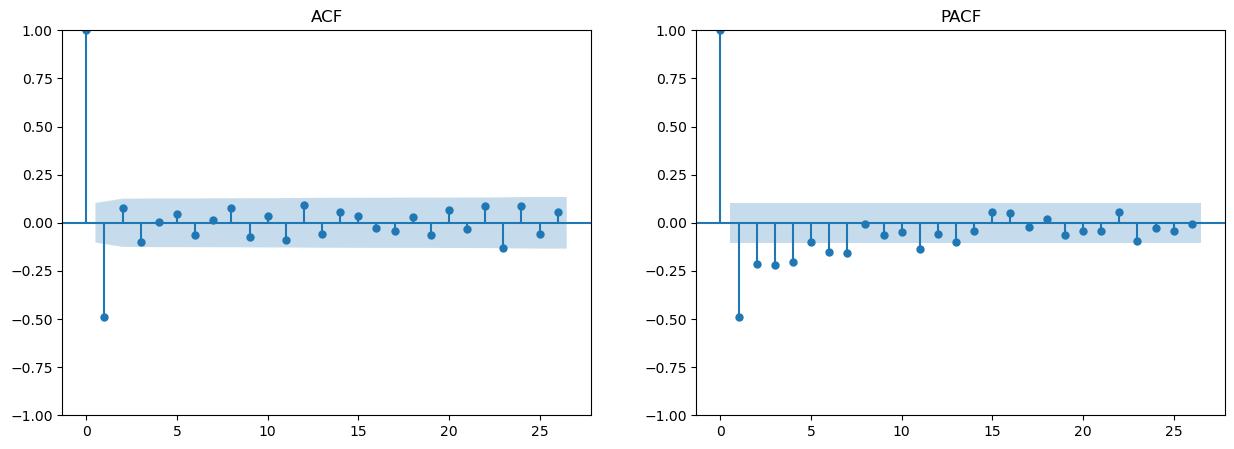

In [5]:
fig, ax = plt.subplots(1, 2, figsize = (15,5)) # 사실 이게 뭔 기준인지 아직도 모르겠음둥 

plot_acf(diff_work, ax = ax[0]) # 위에서 둘로 쨌으니까 한쪽에는 ACF가 들어가고 
ax[0].set_title('ACF')

plot_pacf(diff_work, ax = ax[1]) # 얘는 PACF임다 
ax[1].set_title('PACF')

plt.show()

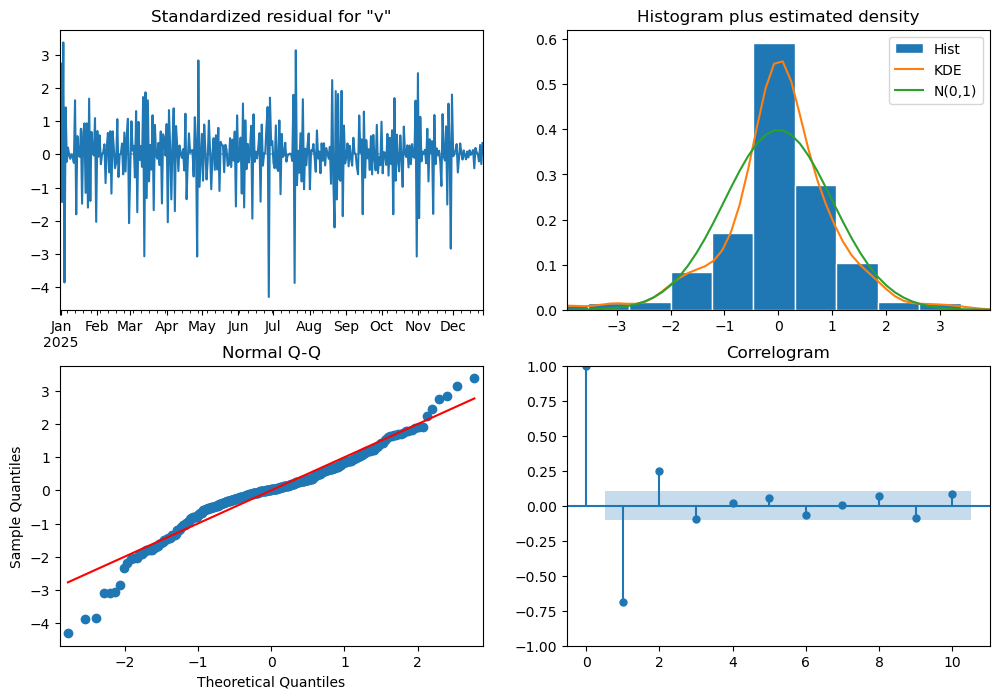

In [ ]:
model = ARIMA(diff_work, order = (0,1,0)) # p, d, q = 0, 1, 0
model_fit = model.fit()

model_fit.plot_diagnostics(figsize=(12, 8)) # 잔차 분석(뭔지 모르겠음...)
plt.show()
# 와 삼전것보다 더 개판이야 

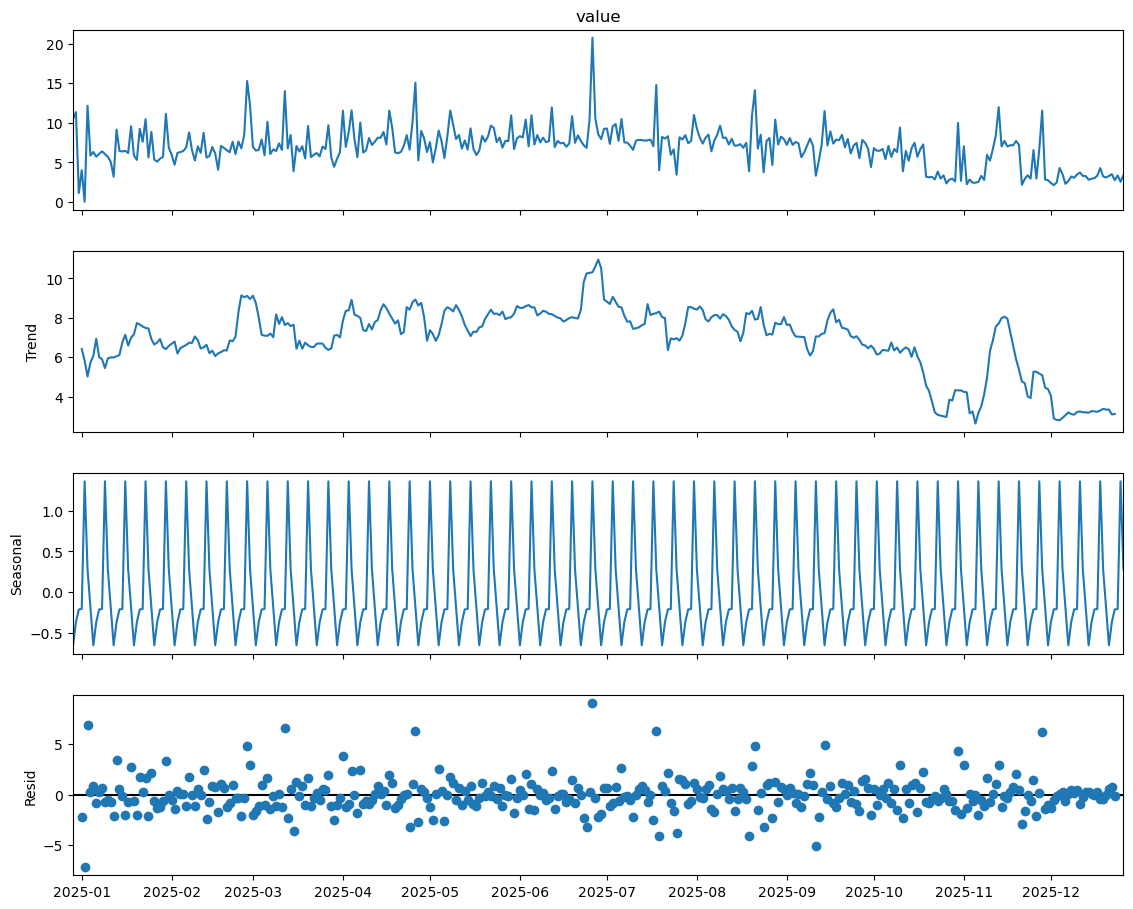

In [7]:
# 1. 시계열 분해 실행 (모델은 더하기 모델 'additive' 추천)
# day_per_work에 날짜 인덱스가 잘 잡혀있어야 합니다.
result = seasonal_decompose(day_per_work, model='additive', period=7)

# 2. 그래프 그리기
fig = result.plot()
fig.set_size_inches(12, 10)
plt.show()